In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import community as community_louvain


from src import utils 

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/nayeliguzman/.local/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
path = './data/skin.xlsx'
df = pd.DataFrame(pd.read_excel(path)) 


In [3]:
#Data cleaning and pre-processing 
#Find important ingredients and analyze
df = utils.clean(df)
df = utils.find_actives(df)
df = utils.find_peptides(df)
df = utils.find_ceramides(df)
df = utils.add_most_similar_column(df)


# Most Similar Products
Using the Jaccard similarity, which treats ingredient lists as sets and measures overlap relative to total unique ingredients, we can see which products are most similar to each other. 0 = completely different; 100 = identical

For every product in the batch we obtain a most similar product and a similarity score. The "most similar product" relation is not symmetric because it depends on a ranking over all candidates, not just pariwise similarity. While simiarity scores between products may be symmetric, the mappint from a product to its most similar counterpart is not. The selection depends on each product's full set of alternatives and their relative similarities. 

Skinceuticals CE Ferulic and Dr Brenner C Serum have a 50% simliarity score which is expected since they both feature vitamin C, vitamin E, and ferulic acid. Product B can be most similar to product A, but product A is not necessarily most similar to product B. 

In [4]:
utils.show_most_similar(df)

,Product,Most Similar,Similarity Score
0,Triple Lipid Restore,Lacome Advanced Genifique Face Serum,16.981132
1,ErnoLaszlo Timeless Serum,Inkey List Hyalouronic Acid,22.222222
2,Eve Lom Radiance Repair Serum,MAELOVE GLOW MAKER SERUM,12.727273
3,111 Skin Y Theorem Repair Light Serum,Irene Forte Hibiscus Night Cream,10.344828
4,Cera Ve Skin Renewing Night Cream,Irene Forte Hibiscus Night Cream,17.460317
5,Irene Forte Hibiscus Night Cream,Cera Ve Skin Renewing Night Cream,17.460317
6,Lacome Advanced Genifique Face Serum,MAELOVE GLOW MAKER SERUM,21.052632
7,Lacome Advanced Genifique Light Pearl Eye Serum,Lacome Advanced Genifique Face Serum,15.384615
8,Skin Medica 0.5 Retinol,Cera Ve Skin Renewing Night Cream,15.625000
9,Skinceuticals CE Ferulic,Dr Brenner C Serum,50.000000


# Ingredient Properties and Data
For each product, this table shows the number of ingredients, key actives, key properties, cautionary notes, and most similar product from the batch. The most similar column can be treated as a recommended alternative. 

In [5]:
utils.show_properties(df)

,Product,# of Ingredients,Actives,Properties,Caution,Most Similar
0,Triple Lipid Restore,38,"[[GLYCERIN], CERAMIDE 3, CERAMIDE EOP]","[humectant, ceramides]",[],Lacome Advanced Genifique Face Serum
1,ErnoLaszlo Timeless Serum,31,"[[MAGNESIUM ASCORBYL PHOSPHATE], [GLYCERIN], P...","[vitamin c, humectant, peptides]",[DO NOT use with AHA/BHA],Inkey List Hyalouronic Acid
2,Eve Lom Radiance Repair Serum,40,"[[ASCORBYL PALMITATE], [RETINOL], [LACTIC ACID...","[vitamin c, retinol, aha-exfoliant, bha-deep e...","[DO NOT use with AHA/BHA, DO NOT use with benz...",MAELOVE GLOW MAKER SERUM
3,111 Skin Y Theorem Repair Light Serum,30,"[[SODIUM ASCORBYL PHOSPHATE], [GLYCERIN], [NIA...","[vitamin c, humectant, niacinamide]","[DO NOT use with AHA/BHA, DO NOT use with AHA/...",Irene Forte Hibiscus Night Cream
4,Cera Ve Skin Renewing Night Cream,40,"[[CITRIC ACID], [SODIUM HYALURONATE, GLYCERIN]...","[aha-exfoliant, humectant, niacinamide, peptid...","[DO NOT use with vit C, DO NOT use with AHA/BHA]",Irene Forte Hibiscus Night Cream
5,Irene Forte Hibiscus Night Cream,34,"[[SODIUM HYALURONATE, GLYCERIN], CERAMIDE NP, ...","[humectant, ceramides]",[],Cera Ve Skin Renewing Night Cream
6,Lacome Advanced Genifique Face Serum,24,"[[ASCORBYL GLUCOSIDE], [SODIUM HYALURONATE, GL...","[vitamin c, humectant]",[DO NOT use with AHA/BHA],MAELOVE GLOW MAKER SERUM
7,Lacome Advanced Genifique Light Pearl Eye Serum,51,"[[ASCORBYL GLUCOSIDE], [LACTIC ACID, CITRIC AC...","[vitamin c, aha-exfoliant, humectant]","[DO NOT use with AHA/BHA, DO NOT use with vit C]",Lacome Advanced Genifique Face Serum
8,Skin Medica 0.5 Retinol,34,"[[RETINOL], [GLYCERIN], [NIACINAMIDE], PALMITO...","[retinol, humectant, niacinamide, peptides, ce...","[DO NOT use with benzoyl peroxide, DO NOT use ...",Cera Ve Skin Renewing Night Cream
9,Skinceuticals CE Ferulic,12,"[[ASCORBIC ACID], [SODIUM HYALURONATE, GLYCERIN]]","[vitamin c, humectant]",[DO NOT use with AHA/BHA],Dr Brenner C Serum


# Compare Two Similar Products
Two similar products are compared to show which ingredients they have in common and how similar they are in their ingredients. From the properties we can see that although they are both humectants, one includes peptides, while the other is an exfoliant. There is no conflict when using these products together, hence no cautonary notes are included in the output. However, using them both might be redundant. 

In [6]:
products=['Inkey List Hyalouronic Acid' , 'Kiels Hyalouronic Acid Serum']
result, batch, similarity, caution= utils.compare_two(df, products)



=== Product Comparison ===



,Product,# of Ingredients,Actives,Properties
12,Inkey List Hyalouronic Acid,13,"[[HYALURONIC ACID, SODIUM HYALURONATE, GLYCERI...","[humectant, peptides]"
13,Kiels Hyalouronic Acid Serum,7,"[[CITRIC ACID], [SODIUM HYALURONATE, GLYCERIN]]","[aha-exfoliant, humectant]"



Shared Ingredients (4):
AQUA, GLYCERIN, PHENOXYETHANOL, SODIUM HYALURONATE

Similarity: 25.00%
No caution flags detected.




Compare two products (Maelove and Dr Brenner) with high similarity to Skinceuticals CE Ferulic. All have the same key properties but Dr Brenner is most similar due to the number of ingredients being identical to Skinceuticals. 

In [7]:
products=['MAELOVE GLOW MAKER SERUM' , 'Skinceuticals CE Ferulic']
result, batch, similarity, caution= utils.compare_two(df, products)



=== Product Comparison ===



,Product,# of Ingredients,Actives,Properties
20,MAELOVE GLOW MAKER SERUM,22,"[[ASCORBIC ACID], [SODIUM HYALURONATE, GLYCERIN]]","[vitamin c, humectant]"
9,Skinceuticals CE Ferulic,12,"[[ASCORBIC ACID], [SODIUM HYALURONATE, GLYCERIN]]","[vitamin c, humectant]"



Shared Ingredients (8):
AQUA, ASCORBIC ACID, ETHOXYDIGLYCOL, FERULIC ACID, GLYCERIN, PHENOXYETHANOL, SODIUM HYALURONATE, TOCOPHEROL

Similarity: 30.77%
No caution flags detected.




In [8]:
products=['Dr Brenner C Serum' , 'Skinceuticals CE Ferulic']
result, batch, similarity, caution= utils.compare_two(df, products)


=== Product Comparison ===



,Product,# of Ingredients,Actives,Properties
10,Dr Brenner C Serum,12,"[[ASCORBIC ACID, L-ASCORBIC ACID], [HYALURONIC...","[vitamin c, humectant]"
9,Skinceuticals CE Ferulic,12,"[[ASCORBIC ACID], [SODIUM HYALURONATE, GLYCERIN]]","[vitamin c, humectant]"



Shared Ingredients (8):
AQUA, ETHOXYDIGLYCOL, GLYCERIN, LAURETH-23, PANTHENOL, PHENOXYETHANOL, PROPYLENE GLYCOL, TRIETHANOLAMINE

Similarity: 50.00%
No caution flags detected.




# Directed Network
By modelling product similarity as a directed network, we observe that nearest neightbor relationships are inherently asymmetric. The graphs reveals central "anchor" products frequently identified as best alternatives, as well as a small number of mutually similar pairs that likely represent true subsitutues. 

Spatial proximity in the graph reflects competitive structure, not just pairwise similarity. When products are mutually similar A<->B they are very close, sometimes overlapping. Very strong overlap happens when there are few other competing connections. Some pairs can form a tight isolated cluster. 
Tight overlaps -> strong substitutes
Looser spacing -> Products are in a category cluster

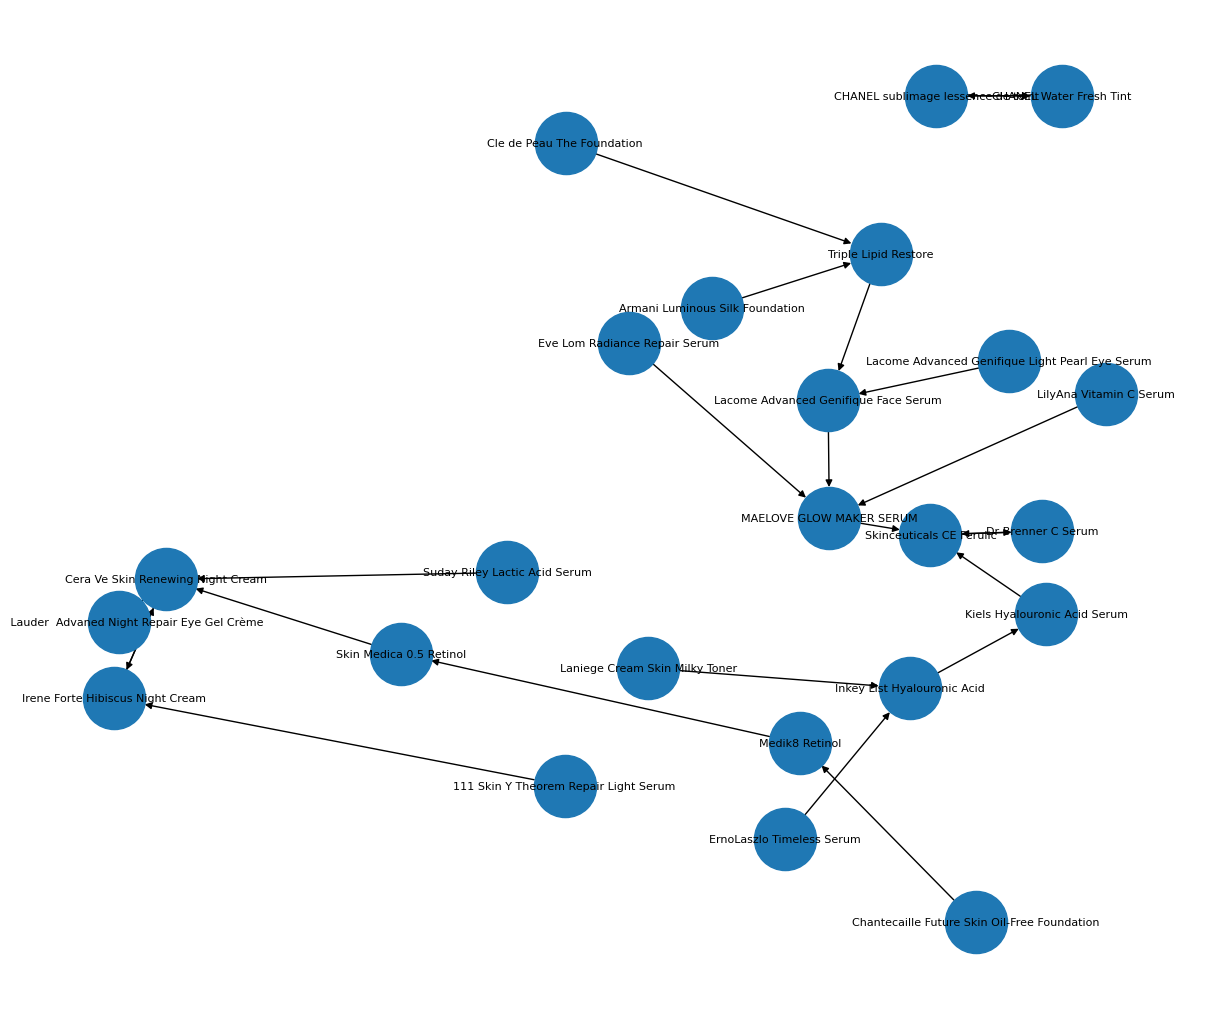

In [9]:

df_visualize = utils.show_most_similar(df)

G = nx.DiGraph()
for _, row in df_visualize.iterrows():
    G.add_edge(row['Product'], row['Most Similar'], weight=row['Similarity Score'])

plt.figure(figsize=(12,10))
pos = nx.spring_layout(G, k=1.2, seed=42)

nx.draw(G, pos, with_labels=True, node_size=2000, font_size=8, arrows=True)
plt.show()

In [10]:
in_degree = dict(G.in_degree())
df['in_degree'] = df['Product'].map(in_degree).fillna(0).astype(int)
incoming_map = df.groupby('Most Similar')['Product'].apply(list).to_dict()
df['incoming_products'] = df['Product'].map(incoming_map)
anchor_threshold = df['in_degree'].max()  # or pick top N

anchors = df.sort_values('in_degree', ascending=False)
top_anchors = df.sort_values('in_degree', ascending=False).head(10)
isolated = df[df['in_degree'] == 0]

In [11]:
anchor_df = pd.DataFrame({
    "Product": list(G.nodes()),
    "in_degree": [G.in_degree(n) for n in G.nodes()],
    "incoming_products": [
        list(G.predecessors(n)) for n in G.nodes()
    ]
})
df['anchor_score'] = df['in_degree'] / df['in_degree'].max()

In [12]:
anchor_df

,Product,in_degree,incoming_products
0,Triple Lipid Restore,2,"[Armani Luminous Silk Foundation, Cle de Peau ..."
1,Lacome Advanced Genifique Face Serum,2,"[Triple Lipid Restore, Lacome Advanced Genifiq..."
2,ErnoLaszlo Timeless Serum,0,[]
3,Inkey List Hyalouronic Acid,2,"[ErnoLaszlo Timeless Serum, Laniege Cream Skin..."
4,Eve Lom Radiance Repair Serum,0,[]
5,MAELOVE GLOW MAKER SERUM,3,"[Eve Lom Radiance Repair Serum, Lacome Advance..."
6,111 Skin Y Theorem Repair Light Serum,0,[]
7,Irene Forte Hibiscus Night Cream,2,"[111 Skin Y Theorem Repair Light Serum, Cera V..."
8,Cera Ve Skin Renewing Night Cream,4,"[Irene Forte Hibiscus Night Cream, Skin Medica..."
9,Lacome Advanced Genifique Light Pearl Eye Serum,0,[]


In [14]:

UG = G.to_undirected()

partition = community_louvain.best_partition(UG)

df['cluster'] = df['Product'].map(partition)

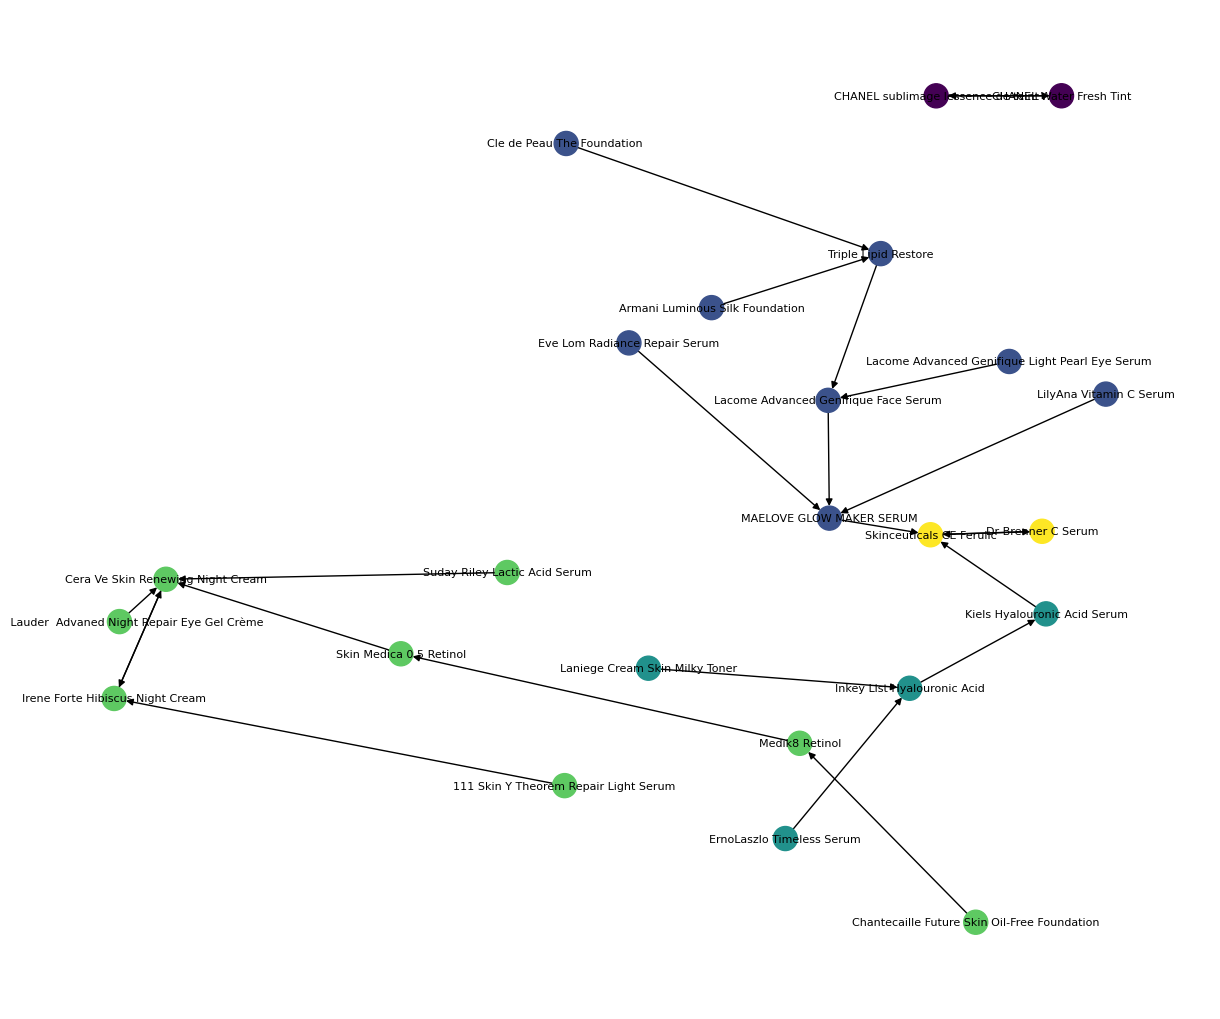

In [15]:

pos = nx.spring_layout(G, k=1.2, seed=42)

plt.figure(figsize=(12,10))

colors = [df.set_index('Product').loc[node, 'cluster'] for node in G.nodes()]

nx.draw(
    G,
    pos,
    node_color=colors,
    with_labels=True,
    node_size=300,
    font_size=8
)

plt.show()

The groups of nodes that are more densely connected to each other are color coded to represent a "product family" with similar ingredient profiles. Clusters that connect to other products either share similar ingredients or are hybrid products. While most clusters are internally dense, cross cluster edges indicate functional overlap between traditionally separate skincare categories. 

In [16]:
df.columns


Index(['Product', 'Ingredients', 'Type', '# of Ingredients', 'Actives',
       'Properties', 'Caution', 'Most Similar', 'Similarity Score',
       'in_degree', 'incoming_products', 'anchor_score', 'cluster'],
      dtype='object')

In [17]:
df.to_csv("data/processed_data/skincare_data.csv", index=False)